# Course 3 Lab: Neural Network Training
## Training a Small Neural Network and Understanding Overfitting

**Teacher / Solutions Notebook**

*Adapted from the UCL Lecturer Toolkit activity 3.7 (AI Long Activity 2).*

> This is the **teacher copy**. It contains the same lab as the student notebook, with every TODO filled in and additional discussion to help you facilitate. Numbers in this notebook match what students will see (same seed, same dataset).

### What students should leave with
1. *Seeing* overfitting on a 2-D dataset (not just inferring it from numbers).
2. Understanding that the same architecture can underfit, overfit, or generalise depending on capacity and regularisation.
3. Connecting the experiment to the bias-variance trade-off. (Step 9 includes a one-line recap of the "Bias & Variance on Paper" models, in case your cohort hasn't done that activity.)

### How to run the session (60 min)
- **10 min**: Welcome; everyone opens the notebook in Colab (File > Save a copy in Drive) and runs Steps 1-4. Quick show of hands: will the BIG model overfit or underfit this dataset?
- **5 min**: Step 5 together. Pause at the BIG-model boundary and ask what they see *before* showing them this notebook.
- **15 min**: Experiment A. Encourage trying multiple sizes before settling.
- **15 min**: Experiment B. Encourage trying multiple alphas.
- **5 min**: Side-by-side comparison + reflection. Make sure they leave with the picture.
- **10 min**: Train-the-trainer debrief: what will your own students struggle with here? Collect the errors people hit into a shared troubleshooting list.


## Step 1: Imports and fixed seed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

SEED = 7
np.random.seed(SEED)
print('Setup done, seed fixed at', SEED)

Setup done, seed fixed at 7


## Step 2: Generate dataset

**Teacher note.** This is `make_moons` deliberately tuned so overfitting is dramatic: only 100 points, noise 0.40. With these settings, a 2×100-neuron MLP will fit the training set to ~95 % but only reach ~77 % on the held-out test set, a 20-point gap students can see in the boundary plot.

If you want to make the effect even stronger, lower `n_samples` to 80 or raise `noise` to 0.45. Don't go past 0.5: the classes start to overlap so much there's no learnable signal.

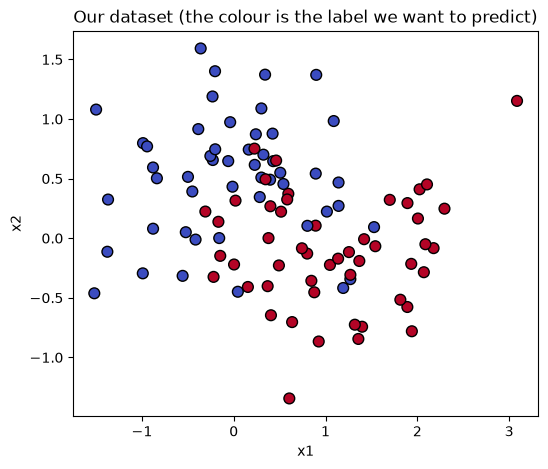

Dataset shape: (100, 2),  class balance: 50/50


In [2]:
X, y = make_moons(n_samples=100, noise=0.40, random_state=SEED)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=60)
plt.title('Our dataset (the colour is the label we want to predict)')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()
print(f'Dataset shape: {X.shape},  class balance: {(y == 0).sum()}/{(y == 1).sum()}')

## Step 3: Train / test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)
print(f'Training points: {len(X_train)},  Test points: {len(X_test)}')

Training points: 70,  Test points: 30


## Step 4: Decision-boundary helper

**Why this matters.** Without the boundary plot, students can only *infer* overfitting from a number gap. With the plot, they **see** the model bending out of its way to chase individual noisy points. That visceral aha-moment is the whole point of this lab.

In [4]:
def plot_decision_boundary(model, X, y, title='', ax=None):
    '''Plot decision boundary of a fitted model on top of data points.'''
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
    ax.set_title(title)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    return ax

print('Helper ready.')

Helper ready.


## Step 5: Baseline BIG model (likely to overfit)

**Expected numbers (SEED=7):** train ≈ 0.957, test ≈ 0.767. A ~20-point gap: textbook overfitting.

BIG model  →  train acc: 0.957   test acc: 0.767
             gap (train - test): +0.190


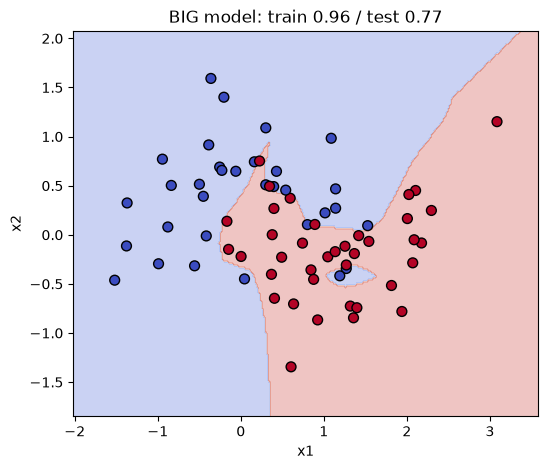

In [5]:
model_big = MLPClassifier(
    hidden_layer_sizes=(100, 100),
    max_iter=3000,
    random_state=SEED,
)
model_big.fit(X_train, y_train)

train_acc_big = accuracy_score(y_train, model_big.predict(X_train))
test_acc_big  = accuracy_score(y_test,  model_big.predict(X_test))
print(f'BIG model  →  train acc: {train_acc_big:.3f}   test acc: {test_acc_big:.3f}')
print(f'             gap (train - test): {train_acc_big - test_acc_big:+.3f}')

plot_decision_boundary(model_big, X_train, y_train,
                       title=f'BIG model: train {train_acc_big:.2f} / test {test_acc_big:.2f}')
plt.show()

**Discussion (teacher).**

Look at the boundary. You'll see narrow blue tongues poking down into the red cluster, and red tongues climbing into the blue cluster: the network has carved out individual training points. None of those bulges represent a real pattern; they're each just one noisy datum.

Anchor question to pose to the group: **"If I show this trained model a brand-new point that lands inside one of those wiggles, what does it predict, and is that prediction trustworthy?"** Most students will realise the answer is *no*, and that explains the test-set drop.

## Step 6: Experiment A (shrink the network)

**Worked solution.** We use `(8,)`: one hidden layer of 8 neurons. That's plenty of capacity for a curved 2-D boundary, but not enough to memorise individual noisy points.

**Expected numbers:** train ≈ 0.800, test ≈ 0.833. The train-test gap is gone; here test accuracy even comes out slightly higher than training accuracy. Don't over-read the exact ordering: with only 30 test points it rests on a single point either way. The signal that matters is that the gap has closed, so the model is generalising rather than memorising.

SMALL model (8,)
  train acc: 0.800   test acc: 0.833
  gap (train - test): -0.033


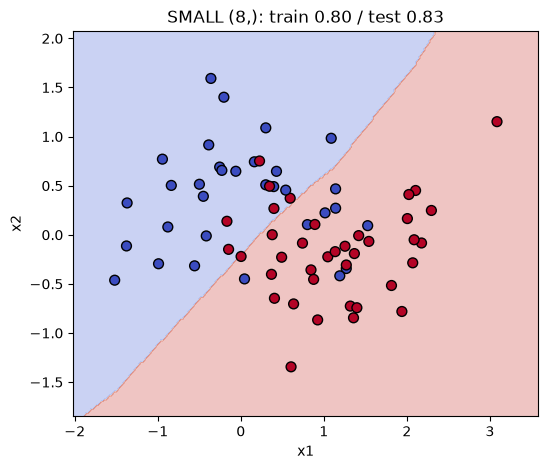

In [6]:
your_hidden_layers = (8,)   # worked solution

model_small = MLPClassifier(
    hidden_layer_sizes=your_hidden_layers,
    max_iter=3000,
    random_state=SEED,
)
model_small.fit(X_train, y_train)

train_acc_small = accuracy_score(y_train, model_small.predict(X_train))
test_acc_small  = accuracy_score(y_test,  model_small.predict(X_test))
print(f'SMALL model {your_hidden_layers}')
print(f'  train acc: {train_acc_small:.3f}   test acc: {test_acc_small:.3f}')
print(f'  gap (train - test): {train_acc_small - test_acc_small:+.3f}')

plot_decision_boundary(model_small, X_train, y_train,
                       title=f'SMALL {your_hidden_layers}: train {train_acc_small:.2f} / test {test_acc_small:.2f}')
plt.show()

**Common student question:** *"Why did training accuracy go DOWN? Doesn't worse training = worse model?"*

**Answer to push them towards:** The big model was achieving high training accuracy by memorising noise. We don't care about that. We care about test accuracy, which is our best proxy for real-world use. Training accuracy dropping while test accuracy rises means the model has stopped memorising and started learning.

## Step 7: Experiment B (same big network, add regularisation)

**Worked solution.** We use `alpha=1.0`: strong L2 regularisation. The optimiser is penalised for large weights, which pushes it toward smoother decision boundaries even when the architecture has capacity to be wiggly.

**Expected numbers:** train ≈ 0.814, test ≈ 0.833. Again, the train-test gap is essentially gone.

REGULARISED model (alpha=1.0)
  train acc: 0.814   test acc: 0.833
  gap (train - test): -0.019


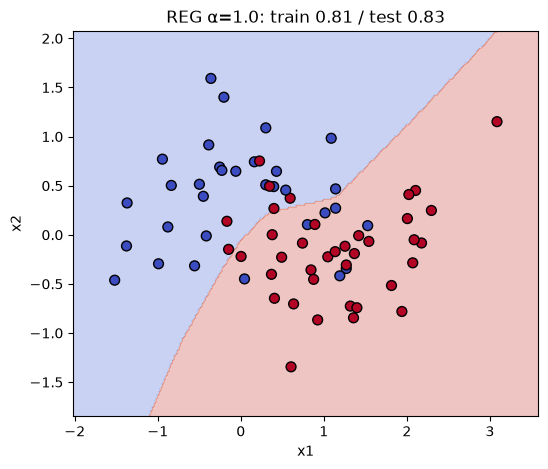

In [7]:
your_alpha = 1.0   # worked solution

model_reg = MLPClassifier(
    hidden_layer_sizes=(100, 100),   # SAME size as the BIG model
    alpha=your_alpha,
    max_iter=3000,
    random_state=SEED,
)
model_reg.fit(X_train, y_train)

train_acc_reg = accuracy_score(y_train, model_reg.predict(X_train))
test_acc_reg  = accuracy_score(y_test,  model_reg.predict(X_test))
print(f'REGULARISED model (alpha={your_alpha})')
print(f'  train acc: {train_acc_reg:.3f}   test acc: {test_acc_reg:.3f}')
print(f'  gap (train - test): {train_acc_reg - test_acc_reg:+.3f}')

plot_decision_boundary(model_reg, X_train, y_train,
                       title=f'REG α={your_alpha}: train {train_acc_reg:.2f} / test {test_acc_reg:.2f}')
plt.show()

**Why this matters pedagogically.** Models 1 and 3 have **the same architecture** (100, 100). The only difference is `alpha`. So the improvement isn't because we made the model smaller; it's because we asked the optimiser to prefer simple solutions among the many that fit the training data.

This is a different lever from Experiment A and worth stressing: in real projects you often **can't** reduce capacity easily (e.g. you're using a pre-trained architecture). Regularisation is the alternative.

## Step 8: Side-by-side comparison

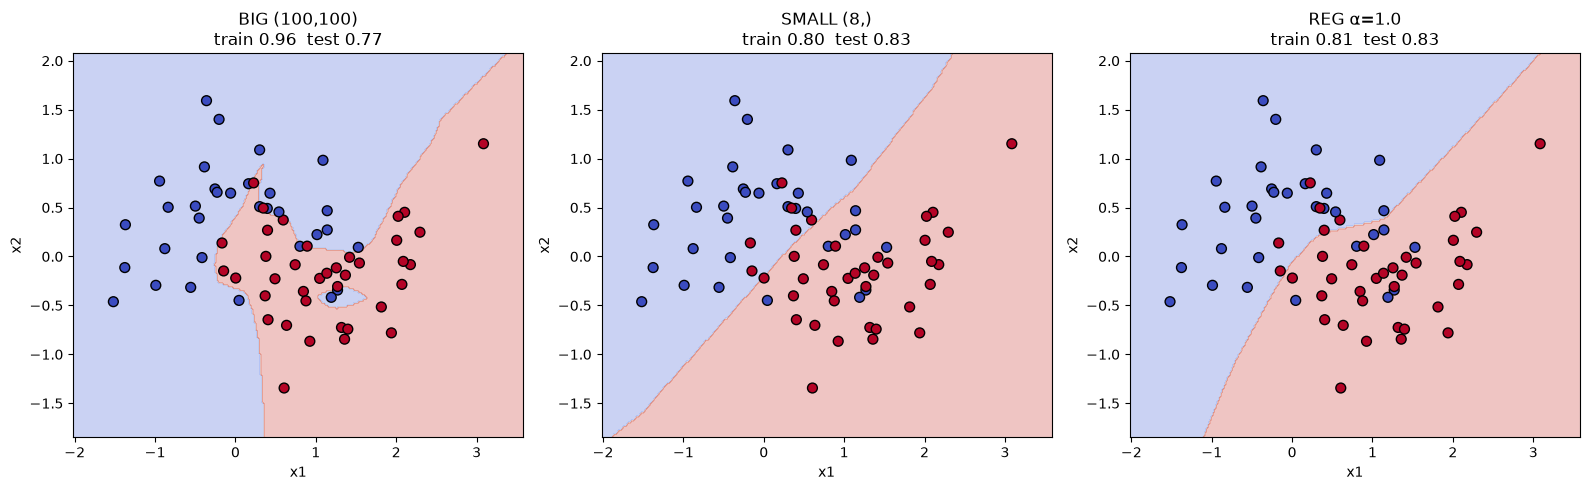


Summary table
Model                     train     test      gap
--------------------------------------------------------
BIG (100,100)             0.957    0.767   +0.190
SMALL (8,)                0.800    0.833   -0.033
REG alpha=1.0             0.814    0.833   -0.019


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_decision_boundary(model_big,   X_train, y_train,
    f'BIG (100,100)\ntrain {train_acc_big:.2f}  test {test_acc_big:.2f}', axes[0])
plot_decision_boundary(model_small, X_train, y_train,
    f'SMALL {your_hidden_layers}\ntrain {train_acc_small:.2f}  test {test_acc_small:.2f}', axes[1])
plot_decision_boundary(model_reg,   X_train, y_train,
    f'REG α={your_alpha}\ntrain {train_acc_reg:.2f}  test {test_acc_reg:.2f}', axes[2])
plt.tight_layout()
plt.show()

print('\nSummary table')
print('=' * 56)
print(f"{'Model':<22} {'train':>8} {'test':>8} {'gap':>8}")
print('-' * 56)
print(f"{'BIG (100,100)':<22} {train_acc_big:>8.3f} {test_acc_big:>8.3f} {train_acc_big - test_acc_big:>+8.3f}")
print(f"{f'SMALL {your_hidden_layers}':<22} {train_acc_small:>8.3f} {test_acc_small:>8.3f} {train_acc_small - test_acc_small:>+8.3f}")
print(f"{f'REG alpha={your_alpha}':<22} {train_acc_reg:>8.3f} {test_acc_reg:>8.3f} {train_acc_reg - test_acc_reg:>+8.3f}")

## Extension A: Alpha sweep (teacher demo)

If you have time, run this sweep to **show the U-curve** that the Bias & Variance on Paper activity drew on the board. As `alpha` increases from tiny to huge, test accuracy first rises (less overfitting), peaks, then falls (too constrained = underfitting). This is the bias-variance trade-off, live.

*This cell is not in the student notebook; use it in the wrap-up if it would help your group.*

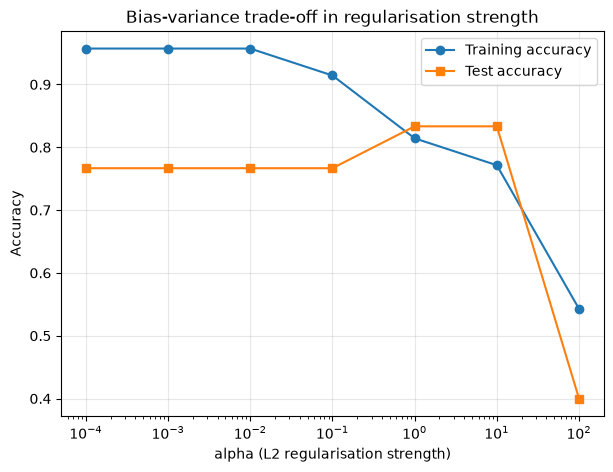

alpha=  0.0001   train=0.957   test=0.767   gap=+0.190
alpha=  0.0010   train=0.957   test=0.767   gap=+0.190
alpha=  0.0100   train=0.957   test=0.767   gap=+0.190
alpha=  0.1000   train=0.914   test=0.767   gap=+0.148
alpha=  1.0000   train=0.814   test=0.833   gap=-0.019
alpha= 10.0000   train=0.771   test=0.833   gap=-0.062
alpha=100.0000   train=0.543   test=0.400   gap=+0.143


In [9]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = [], []

for a in alphas:
    m = MLPClassifier(hidden_layer_sizes=(100, 100), alpha=a,
                      max_iter=3000, random_state=SEED).fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  m.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.semilogx(alphas, train_scores, 'o-', label='Training accuracy')
plt.semilogx(alphas, test_scores,  's-', label='Test accuracy')
plt.xlabel('alpha (L2 regularisation strength)')
plt.ylabel('Accuracy')
plt.title('Bias-variance trade-off in regularisation strength')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

for a, tr, te in zip(alphas, train_scores, test_scores):
    print(f'alpha={a:8.4f}   train={tr:.3f}   test={te:.3f}   gap={tr - te:+.3f}')

**Read the curve with the group.** On the far left, alpha is so tiny it's effectively off: train ≈ 0.96, test ≈ 0.77 (overfitting). On the far right, alpha is so strong the network can't learn at all: training accuracy collapses to chance (underfitting). The sweet spot is in the middle. Connect this to the U-shape they sketched on paper.

**Important follow-up question to ask:** *"How could we have picked the best alpha **without** looking at the test set?"* This leads naturally into the idea of a **validation set**, which is the next logical step in their curriculum.

## Step 9: Reflection, model answers

Numbered to match the five questions in the student notebook.

1. **Highest training vs. highest test accuracy, and why they differ:** the BIG model has the highest *training* accuracy (≈ 0.957); the highest *test* accuracy is shared by SMALL and REG (both ≈ 0.833). They aren't the same model because BIG bought its training accuracy partly by memorising noisy points, and memorisation doesn't transfer to new data. Test accuracy measures the part that *does* transfer.
2. **Where the BIG model is learning noise:** the narrow tongues of blue reaching into the red cluster (and vice versa). Each one is the model contorting itself to fit one or two noisy points.
3. **Did one experiment clearly win?** On this seed they tie: both land at test ≈ 0.833 with the gap essentially gone. That is itself the teaching point: reducing capacity and adding regularisation are two different levers with the same generalisation effect here. Groups that swept other sizes or alphas may see small differences either way; there is no single right answer.
4. **Which to deploy:** SMALL or REG; both generalise. Prefer the simpler one (the small model) all else equal, or the regularised one if you have a reason to keep the architecture fixed.
5. **Bias-variance link:** the BIG unregularised model has **high variance** (very sensitive to which training points it saw). A very tiny model, say `(2,)`, would have **high bias** (too simple to capture the moon shape). Models with moderate capacity or strong regularisation sit closer to the right trade-off.

### Connect back to the math activity
If your cohort has done the "Bias & Variance on Paper" activity, remind them it told exactly this story: Model A (always predict 1) was high bias, Model C (memorise the table) was high variance, Model B (a simple threshold at x = 10) was the trade-off. If they haven't done it, that one-line recap is all they need. Today they saw the same trade-off play out inside an actual neural network.


---
### Teacher checklist before running this in class
- [ ] Confirm scikit-learn version ≥ 1.0 (Colab default works).
- [ ] Run the notebook end-to-end yourself once on the workshop Colab image: expected runtime ≈ 30 seconds total. (Numbers last re-verified 2026-07-30 on scikit-learn 1.9; the seeded results have been stable across versions, but the check is cheap.)
- [ ] Heads-up for the linked online lab (*Lab: Mitigate Overfitting*, AI Research Foundations Course 3): its solution cell has a known upstream bug. The variables `hyperparameters_regularization_medium` / `_high` should be `hyperparameters_weight_decay_medium` / `_high`; rename both if a participant hits the error.
- [ ] If you have the bias-variance worksheet from AI Medium Activity 2, keep it handy as a reference (optional; Step 9 includes the one-line recap).
- [ ] Decide whether you want to use the alpha-sweep extension or skip it.
- [ ] If students finish early, point them at the *"If you finish early"* prompts in the student notebook.
